In [54]:
import numpy as np
import pandas as pd
from model import ProbModel
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import pickle

In [55]:
df = pd.read_csv('../../data/processed/dataset_clean_no-outliers.csv').drop(columns=['Unnamed: 0.1', 'Unnamed: 0'])

In [56]:
# realignment
df['speed'] = df['speed'][6:].reset_index(drop=True)
df['power'] = df['power'][:-6].reset_index(drop=True)

normalized = (df['power'] - df['power'].min()) / (df['power'].max() - df['power'].min()) # normalize
df['power'] = np.clip(normalized, 1e-15, 1 - 1e-15)

df.dropna(inplace=True)

In [4]:
n = len(df)
train_size = int(0.7 * n)
val_size = int(0.2 * n)
test_size = n - train_size - val_size

train_df = df.iloc[:train_size].reset_index(drop=True)
val_df = df.iloc[train_size:train_size + val_size].reset_index(drop=True)
test_df = df.iloc[train_size + val_size:].reset_index(drop=True)

print(train_df.shape)
print(train_df.columns)

(30662, 5)
Index(['datetime', 'speed', 'power', 'price', 'load'], dtype='object')


In [5]:
model = ProbModel(
    binning_method='equal_width',
    interval_params=1,
    spline_k=3,
    spline_s=0.5
)

In [6]:
model.fit(train_df['speed'], train_df['power'])
train_df['pred'] = model.predict(train_df['speed'])
val_df['pred'] = model.predict(val_df['speed'])
test_df['pred'] = model.predict(test_df['speed'])

mse = mean_squared_error(train_df['power'], train_df['pred'])
print(f"Train MSE: {mse}")

mse = mean_squared_error(val_df['power'], val_df['pred'])
print(f"Validation MSE: {mse}")

mse = mean_squared_error(test_df['power'], test_df['pred'])
print(f"Test MSE: {mse}")

Train MSE: 0.031773985788937406
Validation MSE: 0.04089550901394527
Test MSE: 0.03678987265924495


In [7]:
model.get_params()

{'binning_method': 'equal_width',
 'interval_params': 1,
 'spline_k': 3,
 'spline_s': 0.5,
 'smoothing_factor': 0.01,
 'drift_factor': 0.001,
 'reset_prev_w': 0.02}

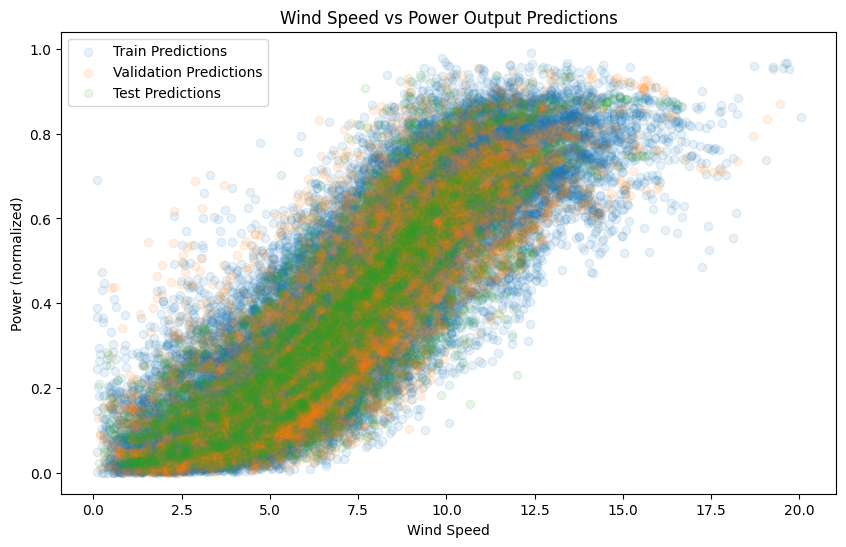

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(train_df['speed'], train_df['pred'], label='Train Predictions', alpha=0.1)
plt.scatter(val_df['speed'], val_df['pred'], label='Validation Predictions', alpha=0.1)
plt.scatter(test_df['speed'], test_df['pred'], label='Test Predictions', alpha=0.1)
plt.xlabel('Wind Speed')
plt.ylabel('Power (normalized)')
plt.title('Wind Speed vs Power Output Predictions')
plt.legend()
plt.show()

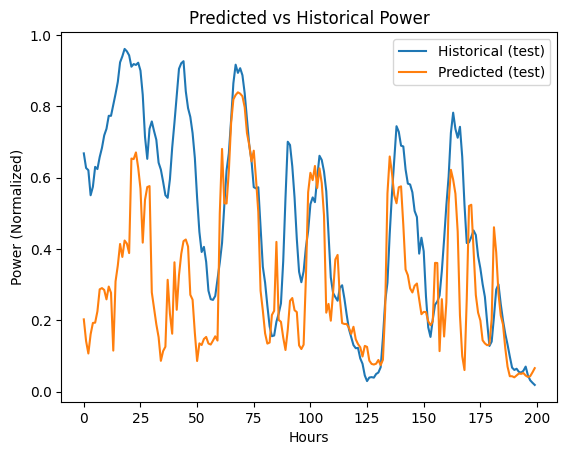

In [9]:
# plt.plot(train_df['power'][:200], label='Historical')
# plt.plot(train_df['pred'][:200], label='Predicted')

# plt.plot(val_df['power'][:200], label='Historical (val)')
# plt.plot(val_df['pred'][:200], label='Predicted (val)')

plt.plot(test_df['power'][0:200].reset_index(drop=True), label='Historical (test)')
plt.plot(test_df['pred'][0:200].reset_index(drop=True), label='Predicted (test)')

plt.xlabel('Hours')
plt.ylabel('Power (Normalized)')
plt.title('Predicted vs Historical Power')
plt.legend()

In [10]:
a_spline = model.get_var('a_spline')
b_spline = model.get_var('b_spline')
lowers, uppers = model.get_var('intervals')

avg_speeds = []
for i in range(len(lowers)):
    lower = lowers[i]
    upper = uppers[i]
    avg_speed = (lower + upper) / 2
    avg_speeds.append(avg_speed)

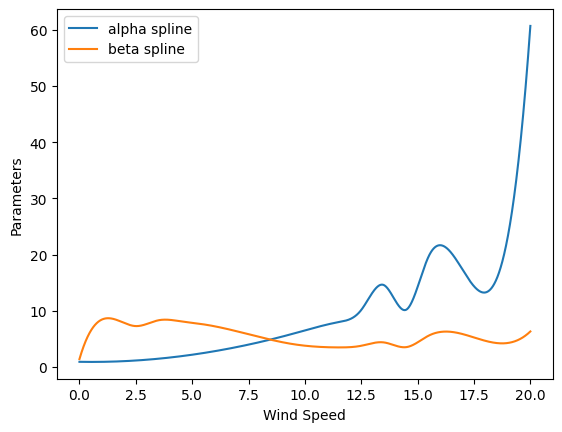

In [11]:
x = np.linspace(0, 20, 10000)
plt.plot(x, a_spline(x), label="alpha spline")
plt.plot(x, b_spline(x), label="beta spline")
plt.xlabel("Wind Speed")
plt.ylabel("Parameters")
plt.legend()

In [12]:
model.fit(train_df['speed'], train_df['power'])

# bayes

In [41]:
from skopt import BayesSearchCV

In [43]:
param_space = {
    'spline_k': [1, 2, 3, 4, 5],
    'spline_s': [0, 0.01, 0.1, 0.5, 1, 2, 5, 25, 100, 250],
    'smoothing_factor': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.2],
    'drift_factor': [0.00001, 0.0001, 0.001, 0.01, 0.1],
    'reset_prev_w': [0.0001, 0.001, 0.01, 0.02, 0.05, 0.1]
}

In [45]:
opt = BayesSearchCV(
    ProbModel(
        binning_method='moving_window',
        interval_params=(1, 0.5),
    ),
    param_space,
    n_iter=50,
    cv=3
)

opt2 = BayesSearchCV(
    ProbModel(
        binning_method='fixed',
        interval_params=[0, 1, 2, 3, 4, 5, 5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.5, 10, 11, 12, 14, 17, 20]
    ),
    param_space,
    n_iter=50,
    cv=3
)

opt3 = BayesSearchCV(
    ProbModel(
        binning_method='equal_freq',
        interval_params=100,
    ),
    param_space,
    n_iter=50,
    cv=3
)

opt4 = BayesSearchCV(
    ProbModel(
        binning_method='equal_width',
        interval_params=0.5
    ),
    param_space,
    n_iter=50,
    cv=3
)

In [47]:
print("Fitting opt1...")
opt.fit(train_df['speed'], train_df['power'])
print("Fitting opt2...")
opt2.fit(train_df['speed'], train_df['power'])
print("Fitting opt3...")
opt3.fit(train_df['speed'], train_df['power'])
print("Fitting opt4...")
opt4.fit(train_df['speed'], train_df['power'])

Fitting opt1...
Fitting opt2...
Fitting opt3...
Fitting opt4...


BayesSearchCV(cv=3, estimator=<model.ProbModel object at 0x15c795ee0>,
              search_spaces={'drift_factor': [1e-05, 0.0001, 0.001, 0.01, 0.1],
                             'reset_prev_w': [0.0001, 0.001, 0.01, 0.02, 0.05,
                                              0.1],
                             'smoothing_factor': [0.0001, 0.001, 0.01, 0.05,
                                                  0.1, 0.2],
                             'spline_k': [1, 2, 3, 4, 5],
                             'spline_s': [0, 0.01, 0.1, 0.5, 1, 2, 5, 25, 100,
                                          250]})

In [52]:
print(opt.best_params_)
print(opt2.best_params_)
print(opt3.best_params_)
print(opt4.best_params_)

OrderedDict({'drift_factor': 0.1, 'reset_prev_w': 0.0001, 'smoothing_factor': 0.001, 'spline_k': 1, 'spline_s': 0})
OrderedDict({'drift_factor': 0.1, 'reset_prev_w': 0.001, 'smoothing_factor': 0.01, 'spline_k': 4, 'spline_s': 1})
OrderedDict({'drift_factor': 0.1, 'reset_prev_w': 0.0001, 'smoothing_factor': 0.001, 'spline_k': 1, 'spline_s': 0.1})
OrderedDict({'drift_factor': 0.1, 'reset_prev_w': 0.0001, 'smoothing_factor': 0.001, 'spline_k': 2, 'spline_s': 0})


# Loading best_model pickle

In [84]:
with open('results/best_model.pkl', 'rb') as f:
    best = pickle.load(f)

In [85]:
best

{'params': {'binning_method': 'equal_width',
  'interval_params': 1,
  'spline_k': 3,
  'spline_s': 0.5,
  'smoothing_factor': 0.01,
  'drift_factor': 0.001,
  'reset_prev_w': 0.02},
 'model': <model.ProbModel at 0x14dd12d20>}

In [86]:
model = best['model']

In [87]:
preds = model.predict(df['speed'])

mse = mean_squared_error(df['power'], preds)
print("MSE:", mse)

MSE: 0.035811208830091874


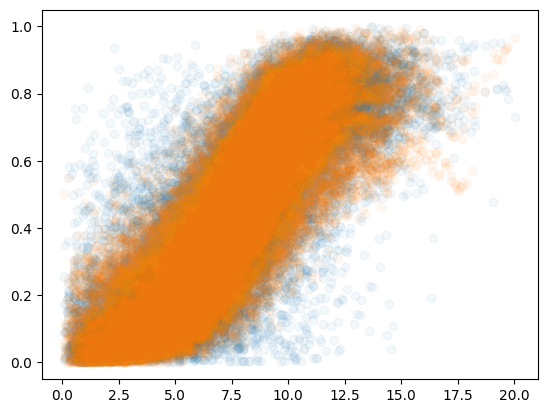

In [88]:
plt.scatter(df['speed'], df['power'], alpha=0.05)
plt.scatter(df['speed'], preds, alpha=0.05)